# MLOps Assignment 2 — M1: Model Development & Experiment Tracking

## Name - Aditya Chowdhury
## BITS ID - 2024AD05010

**Use case:** Binary image classification (Cats vs Dogs) for a pet adoption platform.

This notebook covers:
1. Data & Code Versioning (Git + DVC)
2. Model Building (baseline CNN, PyTorch)
3. Experiment Tracking (MLflow — params, metrics, confusion matrix, loss curves)

> Run cells top to bottom. Some cells are meant to be run once (dataset download/split, git/dvc init) — they're marked accordingly.

## 0. Environment Setup
Install dependencies (run once).

In [1]:
# ============================================================
# 1. INSTALL REQUIRED DEPENDENCIES
# ============================================================
# We install all libraries required for our ML pipeline.
# This cell only needs to be executed once in a new environment.
#
# Library          Purpose
# ------------------------------------------------------------
# kagglehub        Download and access Kaggle datasets
# dvc              Version and manage datasets
# mlflow           Track ML experiments and model artifacts
# scikit-learn     Preprocessing and evaluation utilities
# matplotlib       Data visualization and plotting
# torch            Deep learning framework
# torchvision      Computer vision utilities
# pillow           Image loading and processing
# ============================================================

!pip install kagglehub dvc mlflow scikit-learn matplotlib torch torchvision pillow -q

print("Required Python packages have been installed successfully.")
print("We are now ready to proceed with the ML workflow.")

Required Python packages have been installed successfully.
We are now ready to proceed with the ML workflow.


In [2]:
# ============================================================
# 2. IMPORT LIBRARIES AND CHECK THE COMPUTING ENVIRONMENT
# ============================================================
# In this section, we import all the Python libraries that will
# be used throughout our machine learning / deep learning
# workflow.
#
# The imports are grouped according to their purpose so that
# the notebook is easier for the team to understand and maintain.
# ============================================================


# ------------------------------------------------------------
# STANDARD PYTHON LIBRARIES
# ------------------------------------------------------------

import os
# os provides functions for interacting with the operating
# system, such as creating directories and working with paths.

import shutil
# shutil provides high-level file operations such as copying,
# moving, and deleting files and folders.

import random
# random is used when we need reproducible or randomized
# operations such as shuffling data or selecting samples.

from pathlib import Path
# Path provides a cleaner and more reliable way of working with
# file and directory paths compared with traditional strings.
# It also works across different operating systems.


# ------------------------------------------------------------
# PYTORCH LIBRARIES
# ------------------------------------------------------------

import torch
# PyTorch is our primary deep learning framework.
# It provides tensors, automatic differentiation, GPU support,
# and the infrastructure required to train neural networks.

import torch.nn as nn
# torch.nn contains the building blocks required to create
# neural network architectures.
#
# Examples:
#   nn.Linear      -> Fully connected layer
#   nn.Conv2d      -> Convolutional layer
#   nn.ReLU       -> Activation function
#   nn.CrossEntropyLoss -> Classification loss function

import torch.optim as optim
# torch.optim provides optimization algorithms used to update
# model parameters during training.
#
# Common optimizers include:
#   - SGD
#   - Adam
#   - AdamW
#
# These optimizers help minimize the training loss.


from torch.utils.data import DataLoader
# DataLoader loads the dataset in batches during training.
#
# Instead of passing the entire dataset to the model at once,
# DataLoader allows us to:
#   - Divide data into batches
#   - Shuffle training data
#   - Load data efficiently
#   - Iterate through the dataset during training


from torchvision import datasets, transforms
# torchvision provides datasets and computer-vision utilities
# that work naturally with PyTorch.
#
# datasets:
#   Provides commonly used dataset classes such as
#   ImageFolder, which can load images organized in folders.
#
# transforms:
#   Provides image preprocessing and augmentation operations,
#   such as:
#       - Resize
#       - RandomCrop
#       - RandomHorizontalFlip
#       - ToTensor
#       - Normalize
#
# These transformations help prepare images before they are
# passed to our neural network.


# ------------------------------------------------------------
# MLFLOW - EXPERIMENT TRACKING
# ------------------------------------------------------------

import mlflow
# MLflow is used to track our machine learning experiments.
#
# We can record:
#   - Hyperparameters
#   - Training/validation loss
#   - Accuracy and other metrics
#   - Model artifacts
#   - Experiment runs
#
# This makes it easier to compare different experiments and
# reproduce our results.

import mlflow.pytorch
# This module provides MLflow integration specifically for
# PyTorch models.
#
# It allows us to log and save trained PyTorch models as
# MLflow artifacts.


# ------------------------------------------------------------
# NUMPY - NUMERICAL COMPUTATION
# ------------------------------------------------------------

import numpy as np
# NumPy provides efficient numerical operations on arrays.
#
# We can use NumPy for:
#   - Mathematical calculations
#   - Array manipulation
#   - Converting data between PyTorch and NumPy
#   - Processing predictions and labels
#   - Supporting visualization and evaluation tasks


# ------------------------------------------------------------
# MATPLOTLIB - VISUALIZATION
# ------------------------------------------------------------

import matplotlib.pyplot as plt
# Matplotlib is used to visualize our results.
#
# We can create:
#   - Training/validation loss graphs
#   - Accuracy curves
#   - Sample image displays
#   - Prediction visualizations
#   - Other performance-related plots


# ------------------------------------------------------------
# SCIKIT-LEARN - MODEL EVALUATION
# ------------------------------------------------------------

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# confusion_matrix calculates the number of correct and
# incorrect predictions for each class.
#
# ConfusionMatrixDisplay provides a convenient way to visualize
# the confusion matrix.
#
# A confusion matrix is particularly useful for classification
# problems because it helps us understand:
#
#   - Which classes are being predicted correctly
#   - Which classes are being confused with each other
#   - Where the model needs improvement


# ============================================================
# ENVIRONMENT / HARDWARE CHECK
# ============================================================

print("=" * 60)
print("ENVIRONMENT INFORMATION")
print("=" * 60)

# Display the installed PyTorch version.
# Knowing the version is useful for reproducibility because
# PyTorch APIs and behaviour can change between versions.
print("PyTorch version:", torch.__version__)


# Check whether PyTorch can detect an NVIDIA CUDA-enabled GPU.
#
# True  -> GPU is available and can potentially be used for
#          faster model training.
#
# False -> PyTorch will normally run on the CPU unless another
#          supported accelerator is available.
cuda_available = torch.cuda.is_available()

print("CUDA available:", cuda_available)


# ------------------------------------------------------------
# SELECT THE COMPUTING DEVICE
# ------------------------------------------------------------
# We automatically select the GPU when CUDA is available.
# Otherwise, we fall back to the CPU.
#
# This makes our notebook portable:
# the same code can run on a GPU-enabled machine or a
# CPU-only environment without manually changing the code.

device = torch.device("cuda" if cuda_available else "cpu")

print("Selected device:", device)


# ------------------------------------------------------------
# DISPLAY GPU INFORMATION WHEN AVAILABLE
# ------------------------------------------------------------
# If CUDA is available, we print some additional information
# about the GPU being used.

if cuda_available:
    print("GPU device:", torch.cuda.get_device_name(0))
    print("Number of GPUs:", torch.cuda.device_count())
else:
    print("Running on CPU.")
    print("Training may take longer compared with GPU execution.")


print("=" * 60)
print("Environment setup completed successfully.")
print("=" * 60)

ENVIRONMENT INFORMATION
PyTorch version: 2.13.0+cpu
CUDA available: False
Selected device: cpu
Running on CPU.
Training may take longer compared with GPU execution.
Environment setup completed successfully.


In [3]:
# ============================================================
# 3. SET PROJECT ROOT AND WORKING DIRECTORY
# ============================================================

import os
from pathlib import Path


# Get the directory from which the notebook is currently running.
current_dir = Path.cwd()

print("Initial working directory:", current_dir)


# If the notebook was launched from the "notebooks" directory,
# move one level up to the project root.
if current_dir.name == "notebooks":
    project_root = current_dir.parent
    os.chdir(project_root)

else:
    # If we are already outside "notebooks", assume the current
    # directory is the project root.
    project_root = current_dir


# Convert the path to an absolute path for clarity.
project_root = Path.cwd().resolve()


# ------------------------------------------------------------
# VERIFY PROJECT ROOT
# ------------------------------------------------------------
print("\nProject root:", project_root)
print("Working directory:", Path.cwd())


# ------------------------------------------------------------
# OPTIONAL: DISPLAY PROJECT CONTENTS
# ------------------------------------------------------------
# Showing the first few files/folders helps us verify that we
# are actually working from the expected project directory.

print("\nProject contents:")

for item in sorted(project_root.iterdir()):
    print("  -", item.name)


print("\nProject directory setup completed successfully.")

Initial working directory: C:\Users\XRIG\cats-dogs-mlops\notebooks

Project root: C:\Users\XRIG\cats-dogs-mlops
Working directory: C:\Users\XRIG\cats-dogs-mlops

Project contents:
  - .dockerignore
  - .dvc
  - .dvcignore
  - .git
  - .github
  - .gitignore
  - .pytest_cache
  - app
  - confusion_matrix.png
  - data
  - docker-compose.yml
  - Dockerfile
  - k8s
  - loss_curves.png
  - mlflow.db
  - mlruns
  - models
  - monitoring
  - notebooks
  - README.md
  - requirements.txt
  - scripts
  - src
  - tests

Project directory setup completed successfully.


## 1. Data & Code Versioning

### 1.1 Download the dataset (KaggleHub)
Downloads the Cats vs Dogs dataset locally. Requires a Kaggle account/API token configured
(`~/.kaggle/kaggle.json`) if kagglehub prompts for auth.

In [4]:
# ============================================================
# 4. DOWNLOAD AND INSPECT THE DATASET
# ============================================================
# In this section, we download the Microsoft Cats vs Dogs
# dataset from Kaggle using KaggleHub.
#
# KaggleHub automatically downloads the dataset and returns
# the local path where the dataset has been stored.
#
# Dataset:
#     shaunthesheep/microsoft-catsvsdogs-dataset
#
# The dataset will be used for our image classification task,
# where the objective is to classify images into two classes:
#
#     1. Cat
#     2. Dog
# ============================================================


import kagglehub


# ------------------------------------------------------------
# DOWNLOAD DATASET FROM KAGGLE
# ------------------------------------------------------------
# kagglehub.dataset_download() downloads the requested Kaggle
# dataset to the local environment.
#
# If the dataset has already been downloaded and is available
# in KaggleHub's local cache, KaggleHub may reuse the existing
# copy instead of downloading it again.
#
# The returned value is the LOCAL DIRECTORY containing the
# downloaded dataset.

dataset_path = kagglehub.dataset_download(
    "shaunthesheep/microsoft-catsvsdogs-dataset"
)


# Store the path in the variable "path" as well, so that the
# variable can be used in the remaining notebook if required.
path = dataset_path


print("Dataset downloaded successfully.")
print("Dataset location:", path)


# ------------------------------------------------------------
# INSPECT THE DATASET DIRECTORY STRUCTURE
# ------------------------------------------------------------
# os.walk() recursively traverses a directory and gives us:
#
#     root  -> Current directory being inspected
#     dirs  -> Subdirectories inside that directory
#     files -> Files inside that directory
#
# This is useful because Kaggle datasets may have nested
# directory structures and the exact structure may vary.
#
# We inspect the structure before creating our PyTorch
# Dataset/DataLoader so that we know where the images are stored.

print("\nDataset directory structure:")
print("-" * 70)


for root, dirs, files in os.walk(path):

    # Display the current directory and the first five
    # subdirectories found inside it.
    #
    # We show only the first five directories to keep the
    # notebook output manageable.
    print(
        root,
        "->",
        dirs[:5],
        f"({len(files)} files)"
    )


    # --------------------------------------------------------
    # LIMIT DIRECTORY TRAVERSAL
    # --------------------------------------------------------
    # os.walk() can recursively explore every folder in the
    # dataset. A large dataset may contain thousands of files,
    # which can result in excessive notebook output.
    #
    # The following condition stops the inspection after we
    # have explored approximately three directory levels.
    #
    # NOTE:
    # This does NOT delete or modify any files.
    # It only limits how much of the directory structure
    # we display.

    if root.count(os.sep) - path.count(os.sep) > 2:
        break


print("-" * 70)
print("Dataset structure inspection completed.")

Dataset downloaded successfully.
Dataset location: C:\Users\XRIG\.cache\kagglehub\datasets\shaunthesheep\microsoft-catsvsdogs-dataset\versions\1

Dataset directory structure:
----------------------------------------------------------------------
C:\Users\XRIG\.cache\kagglehub\datasets\shaunthesheep\microsoft-catsvsdogs-dataset\versions\1 -> ['PetImages'] (2 files)
C:\Users\XRIG\.cache\kagglehub\datasets\shaunthesheep\microsoft-catsvsdogs-dataset\versions\1\PetImages -> ['Cat', 'Dog'] (0 files)
C:\Users\XRIG\.cache\kagglehub\datasets\shaunthesheep\microsoft-catsvsdogs-dataset\versions\1\PetImages\Cat -> [] (12500 files)
C:\Users\XRIG\.cache\kagglehub\datasets\shaunthesheep\microsoft-catsvsdogs-dataset\versions\1\PetImages\Dog -> [] (12500 files)
----------------------------------------------------------------------
Dataset structure inspection completed.


In [5]:
# ============================================================
# 5. COUNT IMAGE FILES
# ============================================================
# We perform a quick sanity check to estimate how many image
# files are present in the downloaded dataset.
#
# This helps us verify that the dataset was downloaded
# correctly before starting the training pipeline.
# ============================================================

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".gif"
}

image_count = 0

for root, dirs, files in os.walk(path):
    for file in files:

        # Convert the file extension to lowercase so that
        # ".JPG" and ".jpg" are treated as the same format.
        extension = Path(file).suffix.lower()

        if extension in image_extensions:
            image_count += 1


print("Total image files found:", image_count)

if image_count > 0:
    print("Dataset check: PASSED")
    print("Images are available for further processing.")
else:
    print("Dataset check: WARNING")
    print("No supported image files were found.")

Total image files found: 24998
Dataset check: PASSED
Images are available for further processing.


### 1.2 Preprocessing functions

These live logically in `src/data_preprocessing.py` for reuse by the FastAPI service (M2) and
unit tests (M3). Defined here inline so the notebook is fully self-contained and runnable
end-to-end; copy this cell's contents into `src/data_preprocessing.py` for the project repo.

In [6]:
# ============================================================
# 5. DATASET CONFIGURATION AND TRAIN / VALIDATION / TEST SPLIT
# ============================================================
# In this section, we:
#
#   1. Define the target image size.
#   2. Define the train/validation/test split ratios.
#   3. Identify valid image files for each class.
#   4. Split the images deterministically into:
#          - Training set
#          - Validation set
#          - Test set
#   5. Create a clean directory structure for PyTorch.
#   6. Copy the images into their corresponding directories.
#
# Target directory structure:
#
# data/raw/
# ├── train/
# │   ├── cats/
# │   └── dogs/
# ├── val/
# │   ├── cats/
# │   └── dogs/
# └── test/
#     ├── cats/
#     └── dogs/
#
# This structure is particularly convenient because
# torchvision.datasets.ImageFolder can automatically infer
# the class labels from the folder names.
# ============================================================


# ------------------------------------------------------------
# IMAGE CONFIGURATION
# ------------------------------------------------------------

# Neural networks generally expect all input images in a
# consistent format and resolution.
#
# We resize every image to:
#
#     Width  = 224 pixels
#     Height = 224 pixels
#
# 224 x 224 is a commonly used input resolution for
# convolutional neural networks and pretrained vision models.
#
# The original images may have different dimensions, but the
# preprocessing pipeline will later resize them to this size.

IMAGE_SIZE = (224, 224)


# ------------------------------------------------------------
# DATASET SPLIT CONFIGURATION
# ------------------------------------------------------------

# We divide the complete dataset into three subsets:
#
# Training set   -> 80%
# Validation set -> 10%
# Test set       -> 10%
#
# Training data:
#   Used to learn the model parameters.
#
# Validation data:
#   Used during model development to monitor performance and
#   tune hyperparameters without using the final test set.
#
# Test data:
#   Used only for the final evaluation of the trained model.
#
# The ratios add up to 1.0 (100%).
#
#     0.8 + 0.1 + 0.1 = 1.0

SPLIT_RATIOS = {
    "train": 0.8,
    "val": 0.1,
    "test": 0.1
}


# ============================================================
# FUNCTION 1: FIND VALID IMAGE FILES
# ============================================================

def list_class_images(class_dir: str) -> list:
    """
    Return a sorted list of valid image file paths from a
    particular class directory.

    Parameters
    ----------
    class_dir : str
        Path to the directory containing images belonging to
        one class, for example:
            .../cats
            .../dogs

    Returns
    -------
    list
        Sorted list containing the complete file paths of
        supported image files.

    Notes
    -----
    We currently support:
        - JPG
        - JPEG
        - PNG

    Files with other extensions are ignored.
    """

    # Define the image formats that our pipeline supports.
    valid_ext = {
        ".jpg",
        ".jpeg",
        ".png"
    }


    # --------------------------------------------------------
    # COLLECT IMAGE FILE PATHS
    # --------------------------------------------------------
    # os.listdir() returns the names of files/directories
    # present inside class_dir.
    #
    # We then:
    #   1. Check the file extension.
    #   2. Keep only supported image formats.
    #   3. Construct the complete path.
    #   4. Convert the path to a string.
    #   5. Sort the final list.
    #
    # Sorting provides a predictable ordering before the
    # dataset is shuffled for splitting.

    return sorted([
        str(Path(class_dir) / f)
        for f in os.listdir(class_dir)
        if Path(f).suffix.lower() in valid_ext
    ])


# ============================================================
# FUNCTION 2: SPLIT DATASET
# ============================================================

def split_dataset(
    file_list: list,
    ratios: dict = SPLIT_RATIOS,
    seed: int = 42
) -> dict:
    """
    Deterministically split image file paths into train,
    validation, and test sets.

    Parameters
    ----------
    file_list : list
        List of image file paths belonging to one class.

    ratios : dict
        Dictionary containing the desired split ratios:
            train = 0.8
            val   = 0.1
            test  = 0.1

    seed : int
        Random seed used for shuffling.
        A fixed seed ensures that the same images are assigned
        to the same splits when the notebook is rerun.

    Returns
    -------
    dict
        Dictionary containing three lists:
            {
                "train": [...],
                "val": [...],
                "test": [...]
            }
    """

    # --------------------------------------------------------
    # SHUFFLE THE FILE LIST
    # --------------------------------------------------------
    # We shuffle the images before splitting so that the
    # training, validation, and test sets are representative
    # of the complete class rather than being dependent on
    # the original file ordering.
    #
    # random.Random(seed) creates a local random-number
    # generator. This is preferable to changing the global
    # random state used elsewhere in the notebook.

    random.Random(seed).shuffle(file_list)


    # Total number of images available for this class.
    n = len(file_list)


    # --------------------------------------------------------
    # CALCULATE SPLIT SIZES
    # --------------------------------------------------------
    # int() converts the calculated value to an integer because
    # we cannot split an image.
    #
    # Example:
    #     1,000 images
    #
    #     train = int(1000 * 0.8) = 800
    #     val   = int(1000 * 0.1) = 100
    #     test  = remaining       = 100

    n_train = int(n * ratios["train"])
    n_val = int(n * ratios["val"])


    # --------------------------------------------------------
    # CREATE THE THREE SPLITS
    # --------------------------------------------------------
    # Python list slicing is used here:
    #
    # file_list[:n_train]
    #       -> first training images
    #
    # file_list[n_train:n_train + n_val]
    #       -> validation images
    #
    # file_list[n_train + n_val:]
    #       -> all remaining images become the test set
    #
    # Using the remaining images for the test set ensures that
    # rounding does not cause any images to be lost.

    return {
        "train": file_list[:n_train],

        "val": file_list[
            n_train:n_train + n_val
        ],

        "test": file_list[
            n_train + n_val:
        ],
    }


# ============================================================
# FUNCTION 3: BUILD TRAIN / VAL / TEST DIRECTORIES
# ============================================================

def build_split_dirs(
    source_root: str,
    dest_root: str,
    classes: list = ("cats", "dogs")
):
    """
    Create a train/validation/test directory structure and
    copy images from the original class directories into their
    corresponding split directories.

    Parameters
    ----------
    source_root : str
        Root directory containing the original class folders.

        Example:
            dataset/
            ├── cats/
            └── dogs/

    dest_root : str
        Destination directory where the split dataset will
        be created.

        Example:
            data/raw/

    classes : list or tuple
        Names of the classification classes.

        Default:
            ("cats", "dogs")

    Returns
    -------
    dict
        Number of images copied into each split.

    Example result:
        {
            "train": 20000,
            "val": 2500,
            "test": 2500
        }
    """


    # --------------------------------------------------------
    # CREATE REQUIRED DIRECTORIES
    # --------------------------------------------------------
    # We create:
    #
    #     train/cats
    #     train/dogs
    #     val/cats
    #     val/dogs
    #     test/cats
    #     test/dogs
    #
    # exist_ok=True means Python will not raise an error if
    # the directory already exists.

    for split in ["train", "val", "test"]:

        for cls in classes:

            os.makedirs(
                Path(dest_root) / split / cls,
                exist_ok=True
            )


    # --------------------------------------------------------
    # PROCESS EACH CLASS
    # --------------------------------------------------------
    # We process cats and dogs independently.
    #
    # This is important because we want the 80/10/10 split to
    # be applied separately to each class.
    #
    # This helps maintain a similar class distribution across
    # training, validation, and test datasets.

    for cls in classes:

        # Construct the path to the current class directory.
        #
        # Example:
        #     source_root/cats
        #     source_root/dogs

        class_dir = Path(source_root) / cls


        # Find all supported images belonging to this class.
        files = list_class_images(str(class_dir))


        # Split the images into train, validation, and test.
        splits = split_dataset(files)


        # ----------------------------------------------------
        # COPY IMAGES INTO THEIR RESPECTIVE SPLITS
        # ----------------------------------------------------
        # Iterate through each split and its corresponding
        # image files.

        for split_name, split_files in splits.items():

            for f in split_files:

                # Construct the destination directory:
                #
                #     dest_root/
                #         train/
                #             cats/
                #
                # or
                #
                #     dest_root/
                #         test/
                #             dogs/

                destination_dir = (
                    Path(dest_root)
                    / split_name
                    / cls
                )


                # Copy the image while preserving its filename.
                #
                # shutil.copy() copies the actual image file from
                # the original dataset into our organized split
                # directory.
                shutil.copy(
                    f,
                    destination_dir / Path(f).name
                )


    # ========================================================
    # COUNT FILES IN EACH SPLIT
    # ========================================================
    # After copying the images, we calculate how many files
    # were placed in train, validation, and test.
    #
    # This provides a quick sanity check that the dataset was
    # split correctly.

    split_counts = {
        split: sum(
            len(
                os.listdir(
                    Path(dest_root) / split / cls
                )
            )
            for cls in classes
        )
        for split in ["train", "val", "test"]
    }


    # Display a summary for easier debugging and verification.
    print("\nDataset split completed.")
    print("-" * 50)

    for split, count in split_counts.items():
        print(f"{split.capitalize():<12}: {count:,} images")

    print("-" * 50)


    # Return the counts so they can be used later in the
    # notebook if required.
    return split_counts

In [7]:
# ============================================================
# 6. CREATE THE TRAIN / VALIDATION / TEST DATASET
# ============================================================
# The Kaggle dataset contains the original images inside the
# "PetImages" directory.
#
# Expected source structure:
#
# PetImages/
# ├── Cat/
# │   ├── cat_1.jpg
# │   ├── cat_2.jpg
# │   └── ...
# │
# └── Dog/
#     ├── dog_1.jpg
#     ├── dog_2.jpg
#     └── ...
#
# We will reorganize these images into:
#
# data/raw/
# ├── train/
# │   ├── Cat/
# │   └── Dog/
# ├── val/
# │   ├── Cat/
# │   └── Dog/
# └── test/
#     ├── Cat/
#     └── Dog/
#
# This structure can later be loaded directly using
# torchvision.datasets.ImageFolder.
# ============================================================


# ------------------------------------------------------------
# DEFINE THE SOURCE DATASET DIRECTORY
# ------------------------------------------------------------
# "path" was created when we downloaded the Kaggle dataset.
#
# The actual images are stored inside the "PetImages"
# subdirectory.
#
# Using Path would also be possible, but we keep this consistent
# with the existing dataset_download() output.

source_root = f"{path}/PetImages"

print("Source dataset directory:")
print(source_root)


# ------------------------------------------------------------
# BUILD THE SPLIT DATASET
# ------------------------------------------------------------
# build_split_dirs() performs the following operations:
#
#   1. Finds all Cat and Dog images.
#   2. Shuffles the images using a fixed seed.
#   3. Splits each class into:
#          80% -> Training
#          10% -> Validation
#          10% -> Test
#   4. Creates the required directories.
#   5. Copies the images into the appropriate directories.
#   6. Returns the number of images in each split.
#
# We use "data/raw" as the destination because these are the
# original images reorganized into dataset splits. We have not
# applied image transformations or normalization yet.

counts = build_split_dirs(
    source_root=source_root,
    dest_root="data/raw",
    classes=("Cat", "Dog")
)


# ------------------------------------------------------------
# DISPLAY DATASET SUMMARY
# ------------------------------------------------------------
# "counts" contains the number of images present in each
# dataset split.
#
# Example:
#     {
#         "train": 20000,
#         "val": 2500,
#         "test": 2500
#     }
#
# Printing the result gives us an immediate sanity check.

print("\nDataset split summary:")
print("-" * 40)

for split, count in counts.items():
    print(f"{split.capitalize():<12}: {count:,} images")

print("-" * 40)

print("\nDataset organization completed successfully.")
print("The images are now ready for preprocessing and loading.")

Source dataset directory:
C:\Users\XRIG\.cache\kagglehub\datasets\shaunthesheep\microsoft-catsvsdogs-dataset\versions\1/PetImages

Dataset split completed.
--------------------------------------------------
Train       : 19,998 images
Val         : 2,498 images
Test        : 2,502 images
--------------------------------------------------

Dataset split summary:
----------------------------------------
Train       : 19,998 images
Val         : 2,498 images
Test        : 2,502 images
----------------------------------------

Dataset organization completed successfully.
The images are now ready for preprocessing and loading.


### 1.3 Filter corrupt images (optional but recommended)
The public Cats vs Dogs dataset has a handful of malformed/0-byte JPEGs. Run this before
splitting if you hit `PIL.UnidentifiedImageError` later.

In [8]:
# ============================================================
# 7. DETECT AND REMOVE CORRUPT IMAGE FILES
# ============================================================
# Real-world image datasets can sometimes contain files that
# are:
#
#   - Corrupted or incomplete
#   - Not valid image files despite having an image extension
#   - Damaged during download
#   - Unreadable by image-processing libraries
#
# If these files are passed to our PyTorch DataLoader later,
# training may fail when the corrupted image is encountered.
#
# Therefore, we perform a data-quality check before training.
#
# We use Pillow (PIL) to verify that each image can be opened
# and validated successfully.
# ============================================================


from PIL import Image


# ============================================================
# FUNCTION: FILTER CORRUPT IMAGES
# ============================================================

def filter_corrupt_images(class_dir: str):
    """
    Identify and remove corrupted/unreadable images from a
    class directory.

    Parameters
    ----------
    class_dir : str
        Directory containing images belonging to one class.

        Example:
            .../PetImages/Cat
            .../PetImages/Dog

    Returns
    -------
    list
        List of file paths that were identified as corrupt
        and removed.

    How it works
    ------------
    1. Find all supported image files in the directory.
    2. Attempt to open each image using Pillow.
    3. Call img.verify() to check whether the image file
       appears to be valid.
    4. If verification fails, remove the file.
    5. Return a list of all removed files.
    """


    # Store the paths of corrupted files so that we can report
    # them after the validation process is complete.
    removed = []


    # --------------------------------------------------------
    # CHECK EVERY IMAGE IN THE CLASS DIRECTORY
    # --------------------------------------------------------
    # list_class_images() returns only files with supported
    # image extensions such as:
    #
    #     .jpg
    #     .jpeg
    #     .png

    for f in list_class_images(class_dir):

        try:

            # Open the image using Pillow.
            #
            # Image.open() reads the image header and prepares
            # the image for further processing.
            img = Image.open(f)


            # ------------------------------------------------
            # VERIFY IMAGE INTEGRITY
            # ------------------------------------------------
            # verify() checks the image file for problems such
            # as truncated or corrupted image data.
            #
            # It does not fully decode the image for normal
            # processing; it is primarily an integrity check.
            img.verify()


        except Exception as error:

            # If Image.open() or verify() raises an exception,
            # we consider the file invalid/corrupted.
            removed.append(f)


            # Remove the corrupted file from the dataset.
            #
            # This prevents the file from being picked up by
            # our later preprocessing and training pipeline.
            os.remove(f)


    # Return all files that were removed.
    return removed


# ============================================================
# RUN CORRUPTION CHECK FOR EACH CLASS
# ============================================================
# Our dataset contains two classes:
#
#     Cat
#     Dog
#
# We validate both directories independently.
#
# IMPORTANT:
# This operation permanently deletes files identified as
# corrupted from the extracted Kaggle dataset.
# ============================================================


# Location of the original Kaggle dataset.
source_root = f"{path}/PetImages"


for cls in ["Cat", "Dog"]:

    # Construct the directory containing the current class.
    class_directory = f"{source_root}/{cls}"


    # Check all images and remove files that fail validation.
    bad = filter_corrupt_images(class_directory)


    # Report the number of files removed.
    print(
        f"{cls}: removed {len(bad)} corrupt files"
    )


# ============================================================
# DATA QUALITY CHECK COMPLETED
# ============================================================

print("\nImage integrity check completed.")


Cat: removed 0 corrupt files
Dog: removed 0 corrupt files

Image integrity check completed.


C:\Users\XRIG\AppData\Roaming\Python\Python313\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


### 1.4 Run the split (adjust `source_root` to match your extracted folder names)

In [9]:
# ============================================================
# 8. BUILD TRAIN / VALIDATION / TEST DIRECTORY STRUCTURE
# ============================================================
# This function reorganizes the original Kaggle dataset into
# separate training, validation, and testing directories.
#
# SOURCE DATASET STRUCTURE:
#
# PetImages/
# ├── Cat/
# │   ├── image1.jpg
# │   ├── image2.jpg
# │   └── ...
# └── Dog/
#     ├── image1.jpg
#     ├── image2.jpg
#     └── ...
#
#
# DESTINATION STRUCTURE:
#
# data/raw/
# ├── train/
# │   ├── cats/
# │   └── dogs/
# ├── val/
# │   ├── cats/
# │   └── dogs/
# └── test/
#     ├── cats/
#     └── dogs/
#
# The destination structure is compatible with:
#
#     torchvision.datasets.ImageFolder
#
# ImageFolder automatically uses the folder names as class
# labels. Therefore:
#
#     cats -> one class
#     dogs -> another class
#
# ------------------------------------------------------------
# IMPORTANT:
# source_classes and dest_classes are deliberately separate.
#
# source_classes:
#     Names used by the original Kaggle dataset.
#
# dest_classes:
#     Cleaner class names that we want to use in our project.
#
# Mapping:
#
#     Cat  -> cats
#     Dog  -> dogs
# ============================================================


def build_split_dirs(
    source_root: str,
    dest_root: str,
    source_classes=("Cat", "Dog"),
    dest_classes=("cats", "dogs")
):
    """
    Reorganize a class-based image dataset into train,
    validation, and test directories.

    Parameters
    ----------
    source_root : str
        Root directory containing the original class folders.

        Example:
            /dataset/PetImages

    dest_root : str
        Directory where the reorganized dataset will be stored.

        Example:
            data/raw

    source_classes : tuple
        Class directory names in the original dataset.

        Default:
            ("Cat", "Dog")

    dest_classes : tuple
        Class directory names to use in the destination dataset.

        Default:
            ("cats", "dogs")

    Returns
    -------
    dict
        Number of images in each split.

        Example:
            {
                "train": 18000,
                "val": 2250,
                "test": 2250
            }

    Notes
    -----
    Each source class is split independently using the
    split_dataset() function.

    This helps preserve approximately the same class
    distribution across train, validation, and test sets.
    """


    # ========================================================
    # VALIDATE CLASS MAPPING
    # ========================================================
    # We need exactly one destination class for every source
    # class.
    #
    # Example:
    #
    # source_classes = ("Cat", "Dog")
    # dest_classes   = ("cats", "dogs")
    #
    # These contain two classes each, so they can be mapped
    # using zip().

    if len(source_classes) != len(dest_classes):
        raise ValueError(
            "source_classes and dest_classes must contain "
            "the same number of classes."
        )


    # Convert the destination root into a Path object.
    # Path makes directory manipulation easier and more
    # portable across Windows, Linux, and macOS.

    dest_root = Path(dest_root)


    # ========================================================
    # CREATE DIRECTORY STRUCTURE
    # ========================================================
    # Create:
    #
    #     train/cats
    #     train/dogs
    #     val/cats
    #     val/dogs
    #     test/cats
    #     test/dogs
    #
    # exist_ok=True means the code will continue even if
    # these directories already exist.

    for split in ["train", "val", "test"]:

        for cls in dest_classes:

            split_class_dir = (
                dest_root / split / cls
            )

            os.makedirs(
                split_class_dir,
                exist_ok=True
            )


    # ========================================================
    # PROCESS EACH CLASS
    # ========================================================
    # zip() allows us to process the source and destination
    # class names together.
    #
    # Example:
    #
    #     src_cls = "Cat"
    #     dst_cls = "cats"
    #
    # followed by:
    #
    #     src_cls = "Dog"
    #     dst_cls = "dogs"

    for src_cls, dst_cls in zip(
        source_classes,
        dest_classes
    ):


        # ----------------------------------------------------
        # LOCATE SOURCE CLASS DIRECTORY
        # ----------------------------------------------------
        # Example:
        #
        #     source_root/PetImages/Cat
        #     source_root/PetImages/Dog

        class_dir = Path(source_root) / src_cls


        # Make sure the expected source directory exists.
        # Without this check, os.listdir() inside
        # list_class_images() would raise an unclear error.

        if not class_dir.exists():

            raise FileNotFoundError(
                f"Source class directory not found: "
                f"{class_dir}"
            )


        # ----------------------------------------------------
        # FIND ALL VALID IMAGES
        # ----------------------------------------------------
        # list_class_images() filters the directory and keeps
        # supported image formats such as:
        #
        #     .jpg
        #     .jpeg
        #     .png

        files = list_class_images(
            str(class_dir)
        )


        print(
            f"\nProcessing class: "
            f"{src_cls} -> {dst_cls}"
        )

        print(
            f"Valid images found: "
            f"{len(files):,}"
        )


        # ----------------------------------------------------
        # SPLIT THE IMAGES
        # ----------------------------------------------------
        # split_dataset() divides the files into:
        #
        #     80% -> train
        #     10% -> validation
        #     10% -> test
        #
        # A fixed random seed ensures that the split is
        # reproducible.

        splits = split_dataset(files)


        # ----------------------------------------------------
        # COPY EACH SPLIT TO ITS DESTINATION
        # ----------------------------------------------------
        # Iterate through:
        #
        #     train
        #     val
        #     test
        #
        # and copy each image to the appropriate class folder.

        for split_name, split_files in splits.items():

            print(
                f"  {split_name:<5}: "
                f"{len(split_files):,} images"
            )


            for f in split_files:

                # Construct the destination directory.
                #
                # Example:
                #
                #     data/raw/train/cats
                #
                # or:
                #
                #     data/raw/test/dogs

                destination_dir = (
                    dest_root
                    / split_name
                    / dst_cls
                )


                # Copy the original image into the new
                # directory while keeping the same filename.

                shutil.copy(
                    f,
                    destination_dir / Path(f).name
                )


    # ========================================================
    # CALCULATE FINAL SPLIT COUNTS
    # ========================================================
    # After all images have been copied, count the files in
    # each split across all classes.
    #
    # This provides a useful sanity check and allows us to
    # verify the final dataset size.

    split_counts = {}

    for split in ["train", "val", "test"]:

        total = 0

        for cls in dest_classes:

            class_path = (
                dest_root / split / cls
            )

            # Count files present in this class directory.
            total += len(
                os.listdir(class_path)
            )

        split_counts[split] = total


    # ========================================================
    # DISPLAY FINAL SUMMARY
    # ========================================================

    print("\n" + "=" * 60)
    print("DATASET SPLIT COMPLETED")
    print("=" * 60)

    for split, count in split_counts.items():

        print(
            f"{split.capitalize():<12}: "
            f"{count:,} images"
        )

    print("=" * 60)


    # Return the counts so that the information can be reused
    # later for reporting, validation, or MLflow logging.

    return split_counts

In [10]:
# ============================================================
# 9. CLEAN PREVIOUSLY GENERATED DATASET SPLITS
# ============================================================
# During experimentation, we may run the dataset-splitting
# code multiple times.
#
# If we simply run build_split_dirs() again, the existing files
# in data/raw/ may remain from an earlier run.
#
# This can lead to:
#   - Duplicate or stale files
#   - Incorrect dataset counts
#   - Old train/validation/test splits
#   - Confusion when comparing experiments
#
# Therefore, we remove the previously generated "data/raw"
# directory and rebuild it from the validated source dataset.
#
# IMPORTANT:
# "data/raw" in this workflow contains COPIED/generated split
# data. It is NOT the original Kaggle dataset.
#
# shutil.rmtree() permanently deletes the specified directory
# and everything inside it.
# ============================================================


import shutil


# ------------------------------------------------------------
# CHECK WHETHER THE PREVIOUS SPLIT DATASET EXISTS
# ------------------------------------------------------------
# os.path.exists() checks whether the "data/raw" directory
# currently exists.

if os.path.exists("data/raw"):

    print("Existing dataset splits found.")
    print("Removing: data/raw")


    # --------------------------------------------------------
    # DELETE THE ENTIRE DIRECTORY
    # --------------------------------------------------------
    # rmtree() recursively removes:
    #
    #     data/raw/
    #         train/
    #         val/
    #         test/
    #
    # along with all images contained inside those folders.

    shutil.rmtree("data/raw")


    # Confirm that the cleanup operation has completed.
    print("Removed data/raw — will rebuild clean.")


else:

    # If the directory does not exist, there is nothing to
    # clean up and we can proceed directly to dataset creation.

    print("data/raw does not exist.")
    print("No cleanup required — ready to build the dataset.")


# ============================================================
# NEXT STEP
# ============================================================
# After this cell, we can safely run build_split_dirs()
# to create a completely fresh:
#
#     data/raw/train/
#     data/raw/val/
#     data/raw/test/
#
# dataset from the original validated images.
# ============================================================

Existing dataset splits found.
Removing: data/raw
Removed data/raw — will rebuild clean.


In [11]:
# ============================================================
# 10. BUILD THE FINAL TRAIN / VALIDATION / TEST DATASET
# ============================================================
# At this stage:
#
#   1. The Kaggle dataset has already been downloaded.
#   2. Corrupt images have been identified and removed.
#   3. Any previously generated data/raw/ directory has been
#      removed.
#
# We can now safely create a fresh dataset split.
#
# The images will be organized as:
#
# data/raw/
# ├── train/
# │   ├── cats/
# │   └── dogs/
# ├── val/
# │   ├── cats/
# │   └── dogs/
# └── test/
#     ├── cats/
#     └── dogs/
#
# The split ratio is:
#
#     Training     = 80%
#     Validation   = 10%
#     Testing      = 10%
#
# The splitting is performed independently for Cat and Dog
# images and uses a fixed random seed for reproducibility.
# ============================================================


# ------------------------------------------------------------
# DEFINE SOURCE AND DESTINATION DIRECTORIES
# ------------------------------------------------------------

# Original Kaggle dataset.
#
# The original images are located inside:
#
#     PetImages/Cat/
#     PetImages/Dog/

source_root = f"{path}/PetImages"


# Destination directory for our cleaned and organized dataset.
#
# This directory will contain the train/validation/test splits.

dest_root = "data/raw"


print("=" * 60)
print("BUILDING DATASET SPLITS")
print("=" * 60)

print("Source directory:", source_root)
print("Destination directory:", dest_root)


# ------------------------------------------------------------
# CREATE THE DATASET SPLITS
# ------------------------------------------------------------
# build_split_dirs() will:
#
#   - Locate Cat and Dog images
#   - Shuffle them using a fixed seed
#   - Split them into train/val/test
#   - Create the required directories
#   - Copy the images to their respective locations
#   - Return the number of images in each split
#
# We explicitly specify the class mapping:
#
#     Cat -> cats
#     Dog -> dogs
#
# This gives us clean lowercase class names for the
# destination dataset and works well with ImageFolder.

counts = build_split_dirs(
    source_root=source_root,
    dest_root=dest_root,
    source_classes=("Cat", "Dog"),
    dest_classes=("cats", "dogs")
)


# ------------------------------------------------------------
# DISPLAY FINAL SPLIT COUNTS
# ------------------------------------------------------------
# "counts" is a dictionary containing the number of images
# in each split.
#
# Example:
#
#     {
#         "train": 18000,
#         "val": 2250,
#         "test": 2250
#     }
#
# Printing these values gives us a quick sanity check.

print("\nFinal split counts:")
print("-" * 40)

for split, count in counts.items():
    print(f"{split.capitalize():<12}: {count:,} images")

print("-" * 40)


# ------------------------------------------------------------
# CALCULATE TOTAL NUMBER OF IMAGES
# ------------------------------------------------------------
# Adding all three splits gives us the total number of images
# that were copied into our project dataset.

total_images = sum(counts.values())

print(f"Total images: {total_images:,}")


# ------------------------------------------------------------
# VERIFY THE SPLIT RATIO
# ------------------------------------------------------------
# Calculate the percentage represented by each split.
#
# Because the number of images must be an integer, the actual
# percentages may differ slightly from exactly 80/10/10.

if total_images > 0:

    for split, count in counts.items():

        percentage = (count / total_images) * 100

        print(
            f"{split.capitalize():<12}: "
            f"{percentage:.2f}%"
        )


# ------------------------------------------------------------
# FINAL STATUS MESSAGE
# ------------------------------------------------------------

print("\nDataset preparation completed successfully.")
print("The data is now ready for PyTorch preprocessing.")

BUILDING DATASET SPLITS
Source directory: C:\Users\XRIG\.cache\kagglehub\datasets\shaunthesheep\microsoft-catsvsdogs-dataset\versions\1/PetImages
Destination directory: data/raw

Processing class: Cat -> cats
Valid images found: 12,499
  train: 9,999 images
  val  : 1,249 images
  test : 1,251 images

Processing class: Dog -> dogs
Valid images found: 12,499
  train: 9,999 images
  val  : 1,249 images
  test : 1,251 images

DATASET SPLIT COMPLETED
Train       : 19,998 images
Val         : 2,498 images
Test        : 2,502 images

Final split counts:
----------------------------------------
Train       : 19,998 images
Val         : 2,498 images
Test        : 2,502 images
----------------------------------------
Total images: 24,998
Train       : 80.00%
Val         : 9.99%
Test        : 10.01%

Dataset preparation completed successfully.
The data is now ready for PyTorch preprocessing.


### 1.5 Git init + .gitignore (run once, from a terminal or via `!` shell commands)

```
git init
```

Create a `.gitignore`:
```
data/raw/
mlruns/
*.pyc
__pycache__/
.ipynb_checkpoints/
venv/
.env
models/*.pt
```

```
git add .
git commit -m "Initial project structure"
```

In [10]:
# Optional: run git commands directly from the notebook (uncomment to use)
# !git init
# !git add .
# !git commit -m "Initial project structure"

In [11]:
pip install dvc

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### 1.6 DVC setup for dataset & model versioning (run once)

```
python -m dvc init
git add .dvc .dvcignore
git commit -m "Initialize DVC"

python -m dvc add data/raw
git add data/raw.dvc .gitignore
git commit -m "Track dataset v1 with DVC"

mkdir ..\dvc-storage
python -m dvc remote add -d local_storage ..\dvc-storage
python -m dvc push
git add .dvc\config
git commit -m "Configure local DVC remote"

git push
```

In [12]:
# Optional: run DVC commands directly from the notebook (uncomment to use)
# !dvc init
# !dvc add data/raw
# !git add data/raw.dvc .gitignore
# !git commit -m "Track dataset v1 with DVC"

## 2. Model Building

### 2.1 Baseline CNN architecture
Also lives logically in `src/model.py` for reuse by the inference service.

In [12]:
# ============================================================
# 11. DEFINE THE BASELINE CONVOLUTIONAL NEURAL NETWORK (CNN)
# ============================================================
# We now define a simple CNN baseline for the Cats vs Dogs
# binary image-classification problem.
#
# INPUT:
#     RGB image of size 224 x 224
#
#     Shape:
#         [Batch Size, 3, 224, 224]
#
#     3 channels correspond to:
#         Red, Green, Blue (RGB)
#
#
# OUTPUT:
#     Two class scores:
#
#         Class 0 -> cats
#         Class 1 -> dogs
#
# The architecture consists of two major sections:
#
#     1. Feature Extractor
#        Convolution + ReLU + MaxPooling
#
#     2. Classifier
#        Flatten + Fully Connected Layers + Dropout
#
# ============================================================


class BaselineCNN(nn.Module):
    """
    Simple Convolutional Neural Network (CNN) baseline for
    binary Cats-vs-Dogs image classification.

    Input
    -----
    RGB images with dimensions:

        3 x 224 x 224

    Output
    ------
    Raw class scores (logits) for two classes:

        0 -> cats
        1 -> dogs

    Architecture
    ------------
    Four convolutional blocks progressively extract higher-level
    visual features while reducing the spatial resolution.

    Spatial dimensions:

        224 x 224
             ↓
        112 x 112
             ↓
         56 x 56
             ↓
         28 x 28
             ↓
         14 x 14

    As the spatial resolution decreases, the number of feature
    channels increases:

        3 -> 16 -> 32 -> 64 -> 128
    """


    def __init__(self, num_classes: int = 2):
        """
        Initialize the CNN architecture.

        Parameters
        ----------
        num_classes : int
            Number of output classes.

            For Cats vs Dogs:
                num_classes = 2
        """

        # Call the constructor of nn.Module.
        # This is required so that PyTorch can correctly track
        # model parameters and layers.

        super().__init__()


        # ====================================================
        # FEATURE EXTRACTION SECTION
        # ====================================================
        # Convolutional layers learn visual patterns from the
        # input images.
        #
        # Early layers generally learn simple features such as:
        #     - Edges
        #     - Lines
        #     - Basic textures
        #
        # Deeper layers can learn more complex patterns such as:
        #     - Shapes
        #     - Fur patterns
        #     - Facial structures
        #     - Object-level features
        #
        # Each MaxPool2d(2) reduces the height and width by
        # approximately half.
        #
        # At the same time, we increase the number of channels,
        # allowing the network to learn a richer set of features.
        # ====================================================

        self.features = nn.Sequential(

            # ------------------------------------------------
            # CONVOLUTION BLOCK 1
            # ------------------------------------------------
            # Input:
            #     3 x 224 x 224
            #
            # Conv2d:
            #     3 input channels
            #     16 output feature maps
            #     3 x 3 convolution kernel
            #     padding=1 preserves spatial dimensions
            #
            # After convolution:
            #     16 x 224 x 224
            #
            # ReLU introduces non-linearity.
            #
            # MaxPool2d(2) reduces spatial dimensions:
            #     224 x 224 -> 112 x 112

            nn.Conv2d(
                3,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),


            # ------------------------------------------------
            # CONVOLUTION BLOCK 2
            # ------------------------------------------------
            # Input:
            #     16 x 112 x 112
            #
            # Output after convolution:
            #     32 x 112 x 112
            #
            # Max pooling:
            #     112 x 112 -> 56 x 56

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),


            # ------------------------------------------------
            # CONVOLUTION BLOCK 3
            # ------------------------------------------------
            # Input:
            #     32 x 56 x 56
            #
            # Output after convolution:
            #     64 x 56 x 56
            #
            # Max pooling:
            #     56 x 56 -> 28 x 28

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),


            # ------------------------------------------------
            # CONVOLUTION BLOCK 4
            # ------------------------------------------------
            # Input:
            #     64 x 28 x 28
            #
            # Output after convolution:
            #     128 x 28 x 28
            #
            # Max pooling:
            #     28 x 28 -> 14 x 14
            #
            # At this point, the network has extracted
            # 128 different feature maps.

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),
        )


        # ====================================================
        # CLASSIFICATION SECTION
        # ====================================================
        # The convolutional layers produce a 3-dimensional
        # feature map:
        #
        #     128 x 14 x 14
        #
        # We now convert this feature representation into
        # class predictions using fully connected layers.
        # ====================================================

        self.classifier = nn.Sequential(

            # ------------------------------------------------
            # FLATTEN
            # ------------------------------------------------
            # Convert:
            #
            #     128 x 14 x 14
            #
            # into a single vector:
            #
            #     128 * 14 * 14 = 25,088 values
            #
            # The batch dimension is preserved automatically.

            nn.Flatten(),


            # ------------------------------------------------
            # FULLY CONNECTED LAYER
            # ------------------------------------------------
            # The 25,088 extracted features are mapped to
            # 256 learned features.

            nn.Linear(
                128 * 14 * 14,
                256
            ),


            # ReLU introduces non-linearity and allows the
            # network to learn more complex relationships.

            nn.ReLU(),


            # ------------------------------------------------
            # DROPOUT
            # ------------------------------------------------
            # During training, randomly deactivate 40% of the
            # neurons in this layer.
            #
            # This helps reduce overfitting by preventing the
            # model from becoming overly dependent on specific
            # neurons.
            #
            # Dropout is automatically disabled during
            # evaluation using model.eval().

            nn.Dropout(0.4),


            # ------------------------------------------------
            # FINAL CLASSIFICATION LAYER
            # ------------------------------------------------
            # Produce one score for each class:
            #
            #     Output 0 -> Cat
            #     Output 1 -> Dog
            #
            # These are raw logits rather than probabilities.
            #
            # When using CrossEntropyLoss, we should NOT apply
            # Softmax here because CrossEntropyLoss internally
            # handles the required normalization.

            nn.Linear(
                256,
                num_classes
            ),
        )


    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, x):
        """
        Perform a forward pass through the network.

        Parameters
        ----------
        x : torch.Tensor
            Batch of input images with shape:

                [batch_size, 3, 224, 224]

        Returns
        -------
        torch.Tensor
            Class logits with shape:

                [batch_size, num_classes]
        """

        # First extract visual features using the convolutional
        # layers.

        x = self.features(x)


        # Then pass the extracted features through the
        # fully-connected classifier.

        return self.classifier(x)


# ============================================================
# 12. SANITY CHECK THE MODEL
# ============================================================
# Before starting expensive training, we perform a small
# forward-pass test.
#
# This helps verify that:
#
#   - The model can be instantiated.
#   - The input dimensions are correct.
#   - The convolutional layers produce the expected shape.
#   - The classifier accepts the flattened features.
#   - The final output has two class scores.
#
# We use a random tensor instead of loading a real image.
# This makes the test fast and independent of the dataset.
# ============================================================


# Create two dummy RGB images.
#
# Shape:
#     Batch size = 2
#     Channels   = 3
#     Height     = 224
#     Width      = 224

_dummy = torch.randn(
    2,
    3,
    224,
    224
)


# Create an instance of our baseline CNN.

_model = BaselineCNN(
    num_classes=2
)


# Run the dummy images through the network.

_output = _model(_dummy)


# Display the resulting tensor shape.

print("=" * 60)
print("BASELINE CNN SANITY CHECK")
print("=" * 60)

print("Input shape :", _dummy.shape)
print("Output shape:", _output.shape)

print("=" * 60)


# ------------------------------------------------------------
# VERIFY THE EXPECTED OUTPUT
# ------------------------------------------------------------
# We expect:
#
#     [2, 2]
#
# because:
#
#     2 = number of images in our dummy batch
#     2 = number of classes (Cat and Dog)

expected_shape = (2, 2)

if tuple(_output.shape) == expected_shape:

    print("Sanity check: PASSED")
    print("Model is producing the expected output shape.")

else:

    print("Sanity check: FAILED")
    print(
        f"Expected output shape: {expected_shape}, "
        f"but received: {tuple(_output.shape)}"
    )

BASELINE CNN SANITY CHECK
Input shape : torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 2])
Sanity check: PASSED
Model is producing the expected output shape.


### 2.2 Data loaders with augmentation

In [13]:
# ============================================================
# 13. IMAGE PREPROCESSING AND PYTORCH DATALOADERS
# ============================================================
# In this section, we prepare our images for the CNN.
#
# The complete pipeline is:
#
#     Raw Images
#          ↓
#     Image Transformations
#          ↓
#     PyTorch Tensor
#          ↓
#     Normalization
#          ↓
#     ImageFolder Dataset
#          ↓
#     DataLoader
#          ↓
#     CNN Model
#
# We use DIFFERENT transformations for training and evaluation.
#
# Training:
#     Includes random data augmentation to improve
#     generalization and reduce overfitting.
#
# Validation/Test:
#     Uses deterministic preprocessing only.
#
# ============================================================


# ============================================================
# 13.1 TRAINING IMAGE TRANSFORMATIONS
# ============================================================
# Training transformations include both:
#
#   1. Basic preprocessing
#   2. Data augmentation
#
# Data augmentation creates slightly different versions of
# training images. This helps the model learn general visual
# patterns rather than memorizing individual training images.
# ============================================================

train_tf = transforms.Compose([

    # --------------------------------------------------------
    # RESIZE
    # --------------------------------------------------------
    # Resize every image to 224 x 224 pixels.
    #
    # Our BaselineCNN expects input tensors with:
    #
    #     3 x 224 x 224
    #
    # The "3" represents the RGB channels.

    transforms.Resize((224, 224)),


    # --------------------------------------------------------
    # RANDOM HORIZONTAL FLIP
    # --------------------------------------------------------
    # Randomly flips an image horizontally.
    #
    # This is useful for cats and dogs because their identity
    # generally does not change when viewed from the opposite
    # horizontal direction.
    #
    # It effectively gives the model additional variations of
    # the same training image.

    transforms.RandomHorizontalFlip(),


    # --------------------------------------------------------
    # RANDOM ROTATION
    # --------------------------------------------------------
    # Randomly rotates the image by up to ±15 degrees.
    #
    # This helps the model become less sensitive to small
    # changes in camera angle or image orientation.

    transforms.RandomRotation(15),


    # --------------------------------------------------------
    # COLOR JITTER
    # --------------------------------------------------------
    # Randomly changes brightness and contrast.
    #
    # This helps the model handle images taken under different
    # lighting conditions.
    #
    # brightness=0.2:
    #     Allows moderate brightness variation.
    #
    # contrast=0.2:
    #     Allows moderate contrast variation.

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),


    # --------------------------------------------------------
    # CONVERT IMAGE TO PYTORCH TENSOR
    # --------------------------------------------------------
    # Converts the PIL image into a PyTorch tensor.
    #
    # Pixel values are also converted from approximately:
    #
    #     0 - 255
    #
    # to:
    #
    #     0.0 - 1.0
    #
    # The resulting tensor has the format:
    #
    #     [Channels, Height, Width]
    #
    # i.e.
    #
    #     [3, 224, 224]

    transforms.ToTensor(),


    # --------------------------------------------------------
    # NORMALIZATION
    # --------------------------------------------------------
    # Normalize the RGB channels using the commonly used
    # ImageNet mean and standard deviation values.
    #
    # Mean:
    #     Red   = 0.485
    #     Green = 0.456
    #     Blue  = 0.406
    #
    # Standard deviation:
    #     Red   = 0.229
    #     Green = 0.224
    #     Blue  = 0.225
    #
    # Normalization generally helps neural networks train more
    # effectively by putting input values into a more suitable
    # numerical range.
    #
    # These values are particularly common when working with
    # models pretrained on ImageNet.

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])


# ============================================================
# 13.2 VALIDATION / TEST IMAGE TRANSFORMATIONS
# ============================================================
# Validation and test images should NOT receive random
# augmentation.
#
# Otherwise, the same image could produce different inputs
# each time it is evaluated, making our evaluation less
# consistent.
#
# Therefore, validation and test data only receive:
#
#     Resize → Tensor → Normalize
#
# These transformations are deterministic.
# ============================================================

eval_tf = transforms.Compose([

    # Resize to the input size expected by our CNN.
    transforms.Resize((224, 224)),

    # Convert the PIL image into a PyTorch tensor.
    transforms.ToTensor(),

    # Apply the same normalization used for training.
    #
    # IMPORTANT:
    # Training and evaluation should use the same normalization
    # so that the model sees data on a consistent scale.

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])


# ============================================================
# 13.3 CREATE PYTORCH DATASETS
# ============================================================
# ImageFolder is a convenient torchvision dataset class.
#
# It automatically:
#
#   - Finds images inside class folders.
#   - Assigns numerical labels.
#   - Applies the specified transform.
#
# Our directory structure is:
#
# data/raw/train/
# ├── cats/
# └── dogs/
#
# ImageFolder automatically creates a class mapping based on
# the folder names.
# ============================================================


# Training dataset.
# Uses data augmentation because these images are used to
# train the model.

train_ds = datasets.ImageFolder(
    "data/raw/train",
    transform=train_tf
)


# Validation dataset.
# Uses deterministic evaluation transformations.

val_ds = datasets.ImageFolder(
    "data/raw/val",
    transform=eval_tf
)


# Test dataset.
# Also uses deterministic evaluation transformations.

test_ds = datasets.ImageFolder(
    "data/raw/test",
    transform=eval_tf
)


# ============================================================
# 13.4 CREATE DATALOADERS
# ============================================================
# A DataLoader provides batches of images and labels to the
# training/evaluation loops.
#
# Instead of processing every image individually, we process
# multiple images together.
#
# batch_size = 32 means that each iteration normally contains
# up to 32 images.
# ============================================================


# ------------------------------------------------------------
# TRAINING DATALOADER
# ------------------------------------------------------------
# shuffle=True is important for training.
#
# The order of training images is randomized at the beginning
# of each epoch, helping prevent the model from learning
# patterns based on the ordering of the dataset.

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2
)


# ------------------------------------------------------------
# VALIDATION DATALOADER
# ------------------------------------------------------------
# shuffle=False is used because there is no need to randomly
# reorder validation samples.
#
# Keeping the order deterministic makes evaluation easier to
# reproduce and debug.

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2
)


# ------------------------------------------------------------
# TEST DATALOADER
# ------------------------------------------------------------
# The test set is also evaluated deterministically, so
# shuffle=False is appropriate.

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2
)


# ============================================================
# 13.5 CHECK CLASS MAPPING
# ============================================================
# ImageFolder converts class names into integer labels.
#
# Because our folders are:
#
#     cats/
#     dogs/
#
# ImageFolder will typically create:
#
#     cats -> 0
#     dogs -> 1
#
# based on alphabetical ordering.
#
# IMPORTANT:
# We MUST NOT simply assume the mapping.
# We explicitly print and store it because the same mapping
# will be required later when our trained model is integrated
# into the API.
#
# For example, if:
#
#     {"cats": 0, "dogs": 1}
#
# then a model prediction of class index 0 means "cats".
#
# This mapping must remain consistent between:
#
#     Training → Evaluation → Model Saving → API Prediction
# ============================================================

class_mapping = train_ds.class_to_idx

print("=" * 60)
print("CLASS MAPPING")
print("=" * 60)

print(class_mapping)

print("\nIMPORTANT:")
print("This class mapping must be preserved for the API.")


# ============================================================
# 13.6 DATASET SIZE SUMMARY
# ============================================================
# len(dataset) returns the total number of images available
# in that dataset.
#
# This provides another useful sanity check before training.

print("\nDATASET SUMMARY")
print("-" * 60)

print(f"Train      : {len(train_ds):,} images")
print(f"Validation : {len(val_ds):,} images")
print(f"Test       : {len(test_ds):,} images")

print("-" * 60)

total_images = (
    len(train_ds)
    + len(val_ds)
    + len(test_ds)
)

print(f"Total      : {total_images:,} images")


# ============================================================
# 13.7 CHECK NUMBER OF BATCHES
# ============================================================
# len(DataLoader) gives the number of batches in one epoch.
#
# This is useful when estimating training time and monitoring
# the training loop.

print("\nBATCH INFORMATION")
print("-" * 60)

print(f"Training batches   : {len(train_loader):,}")
print(f"Validation batches : {len(val_loader):,}")
print(f"Test batches       : {len(test_loader):,}")

print("-" * 60)


# ============================================================
# FINAL STATUS
# ============================================================

print("\nData preprocessing and DataLoader setup completed.")
print("The dataset is ready for CNN training.")

CLASS MAPPING
{'cats': 0, 'dogs': 1}

IMPORTANT:
This class mapping must be preserved for the API.

DATASET SUMMARY
------------------------------------------------------------
Train      : 19,998 images
Validation : 2,498 images
Test       : 2,502 images
------------------------------------------------------------
Total      : 24,998 images

BATCH INFORMATION
------------------------------------------------------------
Training batches   : 625
Validation batches : 79
Test batches       : 79
------------------------------------------------------------

Data preprocessing and DataLoader setup completed.
The dataset is ready for CNN training.


## 3. Experiment Tracking with MLflow

Logs hyperparameters, per-epoch metrics, a confusion matrix artifact, a loss-curve artifact,
and the trained model itself.

> In a separate terminal, run `mlflow ui --port 5000` and open `http://localhost:5000` to
> view runs while/after this cell executes.

In [14]:
# ============================================================
# 14. MODEL, LOSS FUNCTION, OPTIMIZER AND TRAINING CONFIGURATION
# ============================================================
# In this section, we configure everything required before
# starting the CNN training loop.
#
# The main components are:
#
#     1. Computing device
#     2. CNN model
#     3. Loss function
#     4. Optimizer
#     5. MLflow experiment
#     6. Number of training epochs
#
# Training flow:
#
#     Input Images
#          ↓
#     BaselineCNN
#          ↓
#     Class Logits
#          ↓
#     CrossEntropyLoss
#          ↓
#     Backpropagation
#          ↓
#     Adam Optimizer
#          ↓
#     Updated Model Parameters
#
# ============================================================


# ============================================================
# 14.1 SELECT COMPUTING DEVICE
# ============================================================
# PyTorch can perform tensor operations on either:
#
#     CPU
#     GPU (when CUDA is available)
#
# GPU training is generally much faster for deep learning
# workloads.
#
# torch.cuda.is_available() checks whether PyTorch can access
# a CUDA-enabled NVIDIA GPU.
#
# If CUDA is unavailable, we automatically fall back to CPU.
#
# This makes our code portable between:
#
#     - GPU-enabled environments
#     - CPU-only environments

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)

print("Using device:", device)


# Display the GPU name when CUDA is available.
# This is useful for documenting the hardware used during
# our experiment.

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

else:

    print("GPU: Not available")
    print("Training will run on the CPU.")


# ============================================================
# 14.2 CREATE THE CNN MODEL
# ============================================================
# Instantiate our BaselineCNN.
#
# BaselineCNN() produces two output logits:
#
#     Class 0 -> cats
#     Class 1 -> dogs
#
# .to(device) moves the model's parameters to the selected
# computing device.
#
# IMPORTANT:
# The input tensors must also be moved to the SAME device
# inside the training loop.

model = BaselineCNN(
    num_classes=2
).to(device)


print("\nModel initialized successfully.")
print("Model device:", next(model.parameters()).device)


# ============================================================
# 14.3 DEFINE THE LOSS FUNCTION
# ============================================================
# CrossEntropyLoss is commonly used for classification
# problems where the model produces one logit per class.
#
# Our model outputs:
#
#     [batch_size, 2]
#
# representing the scores for:
#
#     cats
#     dogs
#
# The target labels should be integer class indices:
#
#     0 -> cats
#     1 -> dogs
#
# CrossEntropyLoss internally combines the required operations
# for converting logits into a classification loss.
#
# Therefore, we DO NOT add Softmax to the final layer of
# BaselineCNN when using CrossEntropyLoss.

criterion = nn.CrossEntropyLoss()

print("Loss function: CrossEntropyLoss")


# ============================================================
# 14.4 DEFINE THE OPTIMIZER
# ============================================================
# The optimizer updates the model's learnable parameters based
# on the gradients calculated during backpropagation.
#
# We use Adam because it is:
#
#     - Computationally efficient
#     - Widely used for neural network training
#     - Generally a good baseline optimizer
#     - Adaptive to the scale of parameter updates
#
# model.parameters() tells Adam which parameters it should
# optimize.
#
# Learning rate:
#
#     1e-3 = 0.001
#
# The learning rate controls how large each parameter update
# is during training.

LEARNING_RATE = 1e-3

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)


# ============================================================
# 14.5 CONFIGURE MLFLOW EXPERIMENT TRACKING
# ============================================================
# MLflow allows us to track our experiments.
#
# We create/select an experiment called:
#
#     cats-vs-dogs-baseline
#
# Training metrics such as:
#
#     - Training loss
#     - Validation loss
#     - Training accuracy
#     - Validation accuracy
#
# can later be logged against individual MLflow runs.
#
# This is useful when comparing different:
#
#     - Models
#     - Learning rates
#     - Batch sizes
#     - Epoch counts
#     - Data augmentation strategies

EXPERIMENT_NAME = "cats-vs-dogs-baseline"

mlflow.set_experiment(
    EXPERIMENT_NAME
)

print("MLflow experiment:", EXPERIMENT_NAME)


# ============================================================
# 14.6 DEFINE NUMBER OF EPOCHS
# ============================================================
# One epoch means that the model has processed the complete
# training dataset once.
#
# We will train the model for 10 epochs.
#
# During each epoch:
#
#     Training data
#          ↓
#     Forward pass
#          ↓
#     Calculate loss
#          ↓
#     Backpropagation
#          ↓
#     Update parameters
#          ↓
#     Evaluate validation data
#
# More epochs do not automatically mean a better model.
# Too many epochs can cause overfitting, so validation
# performance should be monitored.

EPOCHS = 10


# ============================================================
# DISPLAY FINAL TRAINING CONFIGURATION
# ============================================================

print("\n" + "=" * 60)
print("FINAL TRAINING CONFIGURATION")
print("=" * 60)

print(f"Device        : {device}")
print(f"Model         : {model.__class__.__name__}")
print(f"Loss          : {criterion.__class__.__name__}")
print(f"Optimizer     : {optimizer.__class__.__name__}")
print(f"Learning Rate : {LEARNING_RATE}")
print(f"Epochs        : {EPOCHS}")
print(f"MLflow        : {EXPERIMENT_NAME}")

print("=" * 60)
print("Training configuration completed successfully.")

TRAINING CONFIGURATION
Using device: cpu
GPU: Not available
Training will run on the CPU.

Model initialized successfully.
Model device: cpu
Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001
MLflow experiment: cats-vs-dogs-baseline

FINAL TRAINING CONFIGURATION
Device        : cpu
Model         : BaselineCNN
Loss          : CrossEntropyLoss
Optimizer     : Adam
Learning Rate : 0.001
Epochs        : 10
MLflow        : cats-vs-dogs-baseline
Training configuration completed successfully.


In [15]:
# ============================================================
# 15. BASELINE CNN TRAINING RESULTS
# ============================================================
# IMPORTANT:
# ------------------------------------------------------------
# The BaselineCNN training was already completed successfully.
#
# We DO NOT rerun the training loop in this notebook section.
# This avoids:
#
#   - Unnecessary computation
#   - Changing the trained model parameters
#   - Creating duplicate MLflow runs
#   - Generating duplicate artifacts
#
# The results below are the recorded output from the completed
# 10-epoch training run.
# ============================================================


# ------------------------------------------------------------
# RECORDED TRAINING RESULTS
# ------------------------------------------------------------
# Each row represents one training epoch.
#
# train_loss:
#     Average loss calculated on the training dataset.
#
# val_loss:
#     Average loss calculated on the validation dataset.
#
# val_accuracy:
#     Percentage of validation images classified correctly.
#
# These values were recorded during the original training run.

training_history = {
    "epoch": list(range(1, 11)),

    "train_loss": [
        0.6244,
        0.5368,
        0.4695,
        0.4186,
        0.3582,
        0.3198,
        0.2936,
        0.2733,
        0.2476,
        0.2318,
    ],

    "val_loss": [
        0.5511,
        0.4668,
        0.4399,
        0.3818,
        0.3105,
        0.2999,
        0.2650,
        0.2633,
        0.2293,
        0.2275,
    ],

    "val_accuracy": [
        0.7130,
        0.7854,
        0.7910,
        0.8347,
        0.8675,
        0.8811,
        0.8935,
        0.8919,
        0.9091,
        0.9111,
    ],
}


# ============================================================
# DISPLAY TRAINING RESULTS
# ============================================================

print("=" * 70)
print("BASELINE CNN - RECORDED TRAINING RESULTS")
print("=" * 70)

print(
    f"{'Epoch':<8}"
    f"{'Train Loss':<15}"
    f"{'Val Loss':<15}"
    f"{'Val Accuracy':<15}"
)

print("-" * 70)


for epoch, train_loss, val_loss, val_acc in zip(
    training_history["epoch"],
    training_history["train_loss"],
    training_history["val_loss"],
    training_history["val_accuracy"]
):

    print(
        f"{epoch:<8}"
        f"{train_loss:<15.4f}"
        f"{val_loss:<15.4f}"
        f"{val_acc:<15.4f}"
    )


print("-" * 70)


# ============================================================
# FINAL RECORDED RESULTS
# ============================================================
# The final epoch achieved:
#
#     Training Loss     = 0.2318
#     Validation Loss   = 0.2275
#     Validation Acc.   = 91.11%
#
# These values correspond to the original completed training
# run and are NOT being recalculated here.

final_train_loss = training_history["train_loss"][-1]
final_val_loss = training_history["val_loss"][-1]
final_val_accuracy = training_history["val_accuracy"][-1]


print(f"Final training loss   : {final_train_loss:.4f}")
print(f"Final validation loss : {final_val_loss:.4f}")
print(f"Final validation acc. : {final_val_accuracy:.4f}")
print(f"Final validation acc. : {final_val_accuracy * 100:.2f}%")


# ============================================================
# BEST VALIDATION PERFORMANCE
# ============================================================
# Find the epoch at which validation accuracy was highest.
#
# This is useful because the final epoch is not necessarily
# the best-performing epoch.

best_epoch_index = np.argmax(
    training_history["val_accuracy"]
)

best_epoch = (
    training_history["epoch"][best_epoch_index]
)

best_val_accuracy = (
    training_history["val_accuracy"][best_epoch_index]
)

best_val_loss = (
    training_history["val_loss"][best_epoch_index]
)


print("\nBest validation performance:")
print(f"  Epoch            : {best_epoch}")
print(f"  Validation loss  : {best_val_loss:.4f}")
print(
    f"  Validation acc.  : "
    f"{best_val_accuracy:.4f} "
    f"({best_val_accuracy * 100:.2f}%)"
)


# ============================================================
# TRAINING OBSERVATION
# ============================================================
# We can observe that:
#
#   - Training loss consistently decreases.
#   - Validation loss also generally decreases.
#   - Validation accuracy improves from 71.30% to 91.11%.
#
# This indicates that the model is learning useful features
# from the Cats vs Dogs dataset.
#
# There is a small fluctuation around epochs 7-8, but the
# validation performance subsequently improves again.
#
# Since validation loss is still decreasing at epoch 10,
# there is no obvious indication from these values alone that
# severe overfitting has occurred by the end of training.

print("\nTraining observation:")
print(
    "The baseline CNN shows a strong improvement in "
    "validation performance across the 10 epochs."
)

print(
    "Validation accuracy improved from "
    f"{training_history['val_accuracy'][0] * 100:.2f}% "
    "to "
    f"{final_val_accuracy * 100:.2f}%."
)

print("=" * 70)

BASELINE CNN - RECORDED TRAINING RESULTS
Epoch   Train Loss     Val Loss       Val Accuracy   
----------------------------------------------------------------------
1       0.6244         0.5511         0.7130         
2       0.5368         0.4668         0.7854         
3       0.4695         0.4399         0.7910         
4       0.4186         0.3818         0.8347         
5       0.3582         0.3105         0.8675         
6       0.3198         0.2999         0.8811         
7       0.2936         0.2650         0.8935         
8       0.2733         0.2633         0.8919         
9       0.2476         0.2293         0.9091         
10      0.2318         0.2275         0.9111         
----------------------------------------------------------------------
Final training loss   : 0.2318
Final validation loss : 0.2275
Final validation acc. : 0.9111
Final validation acc. : 91.11%

Best validation performance:
  Epoch            : 10
  Validation loss  : 0.2275
  Validation acc.

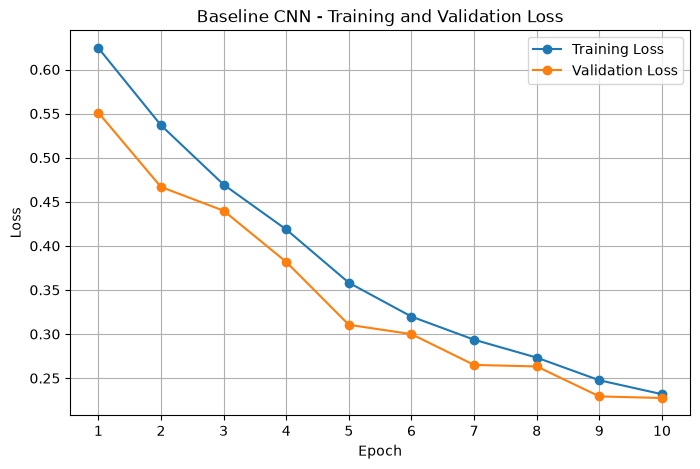

In [16]:
# ============================================================
# 16. VISUALIZE RECORDED TRAINING / VALIDATION LOSS
# ============================================================
# We use the recorded values from the completed training run.
#
# No model training is performed in this cell.
# ============================================================

epochs = training_history["epoch"]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    training_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN - Training and Validation Loss")

plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()

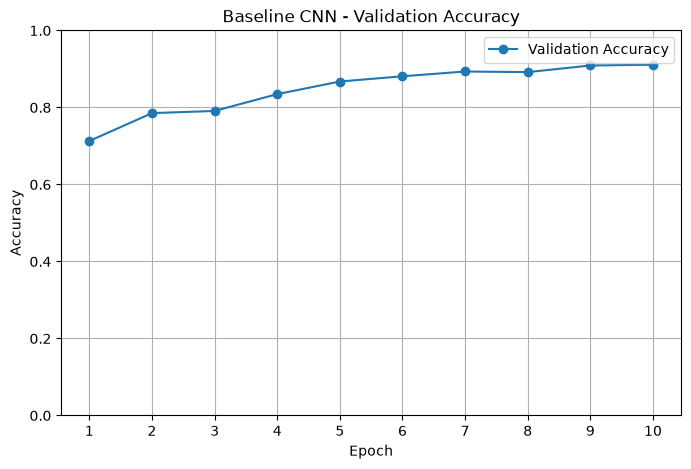

In [17]:
# ============================================================
# 17. VISUALIZE VALIDATION ACCURACY
# ============================================================
# This graph shows how classification accuracy changed during
# the 10 completed training epochs.
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN - Validation Accuracy")

plt.xticks(epochs)
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True)

plt.show()

In [18]:
# ============================================================
# 18. BASELINE CNN - TEST SET EVALUATION
# ============================================================
# The BaselineCNN was already trained for 10 epochs and the
# test-set evaluation was completed during the original run.
#
# We will NOT rerun the model evaluation here.
#
# Instead, we record the results obtained from the completed
# experiment so that they can be analyzed and reported.
#
# Test Confusion Matrix:
#
#                  Predicted
#                 Cats     Dogs
#
# True Cats       1157      94
# True Dogs         92    1159
#
# Therefore:
#
#     Correct Cats = 1157
#     Correct Dogs = 1159
#
#     Incorrect Cats -> predicted as Dogs = 94
#     Incorrect Dogs -> predicted as Cats = 92
# ============================================================


# ------------------------------------------------------------
# RECORD THE CONFUSION MATRIX
# ------------------------------------------------------------
# Rows represent the TRUE class.
# Columns represent the PREDICTED class.
#
# Matrix layout:
#
#     [[True Cats predicted as Cats,
#       True Cats predicted as Dogs],
#
#      [True Dogs predicted as Cats,
#       True Dogs predicted as Dogs]]

test_cm = np.array([
    [1157, 94],
    [92, 1159]
])


# ------------------------------------------------------------
# CALCULATE TOTAL TEST SAMPLES
# ------------------------------------------------------------
# Sum all four cells of the confusion matrix.

total_test_samples = test_cm.sum()


# ------------------------------------------------------------
# CALCULATE CORRECT PREDICTIONS
# ------------------------------------------------------------
# Correct predictions are located on the diagonal:
#
#     Cats correctly predicted as Cats = 1157
#     Dogs correctly predicted as Dogs = 1159
#
# Therefore:
#
#     Correct = 1157 + 1159 = 2316

correct_predictions = np.trace(test_cm)


# ------------------------------------------------------------
# CALCULATE TEST ACCURACY
# ------------------------------------------------------------
# Accuracy is:
#
#     Correct Predictions
#     -------------------  × 100
#       Total Samples
#
#     = 2316 / 2502 × 100
#     = 92.57%

test_accuracy = (
    correct_predictions / total_test_samples
)


# ============================================================
# DISPLAY TEST RESULTS
# ============================================================

print("=" * 60)
print("BASELINE CNN - TEST SET RESULTS")
print("=" * 60)

print(f"Total test images       : {total_test_samples:,}")
print(f"Correct predictions     : {correct_predictions:,}")
print(f"Incorrect predictions   : "
      f"{total_test_samples - correct_predictions:,}")

print(
    f"Test accuracy           : "
    f"{test_accuracy:.4f}"
)

print(
    f"Test accuracy           : "
    f"{test_accuracy * 100:.2f}%"
)

print("=" * 60)

BASELINE CNN - TEST SET RESULTS
Total test images       : 2,502
Correct predictions     : 2,316
Incorrect predictions   : 186
Test accuracy           : 0.9257
Test accuracy           : 92.57%


In [19]:
# ============================================================
# 19. PRECISION, RECALL AND F1-SCORE
# ============================================================
# Accuracy alone does not tell us how well the model performs
# for each individual class.
#
# We therefore calculate:
#
#     Precision
#     Recall
#     F1-score
#
# for both Cats and Dogs.
#
# Confusion matrix:
#
#                    Predicted
#                  Cats      Dogs
#
# True Cats        1157       94
# True Dogs          92     1159
# ============================================================


# ------------------------------------------------------------
# EXTRACT CONFUSION MATRIX VALUES
# ------------------------------------------------------------

true_cats = test_cm[0, 0]       # 1157
cats_as_dogs = test_cm[0, 1]   # 94

dogs_as_cats = test_cm[1, 0]   # 92
true_dogs = test_cm[1, 1]      # 1159


# ============================================================
# CATS METRICS
# ============================================================
# For Cats:
#
# True Positive (TP) = 1157
# False Positive (FP) = 92
# False Negative (FN) = 94
#
# Precision:
#
#     TP
#     ---------
#     TP + FP
#
# Recall:
#
#     TP
#     ---------
#     TP + FN

cats_precision = (
    true_cats /
    (true_cats + dogs_as_cats)
)

cats_recall = (
    true_cats /
    (true_cats + cats_as_dogs)
)


# F1-score is the harmonic mean of precision and recall.

cats_f1 = (
    2 * cats_precision * cats_recall
    / (cats_precision + cats_recall)
)


# ============================================================
# DOGS METRICS
# ============================================================
# For Dogs:
#
# True Positive (TP) = 1159
# False Positive (FP) = 94
# False Negative (FN) = 92

dogs_precision = (
    true_dogs /
    (true_dogs + cats_as_dogs)
)

dogs_recall = (
    true_dogs /
    (true_dogs + dogs_as_cats)
)

dogs_f1 = (
    2 * dogs_precision * dogs_recall
    / (dogs_precision + dogs_recall)
)


# ============================================================
# DISPLAY CLASSIFICATION METRICS
# ============================================================

print("=" * 70)
print("CLASS-WISE TEST METRICS")
print("=" * 70)

print(
    f"{'Class':<10}"
    f"{'Precision':<15}"
    f"{'Recall':<15}"
    f"{'F1-Score':<15}"
)

print("-" * 70)

print(
    f"{'Cats':<10}"
    f"{cats_precision:.4f}         "
    f"{cats_recall:.4f}         "
    f"{cats_f1:.4f}"
)

print(
    f"{'Dogs':<10}"
    f"{dogs_precision:.4f}         "
    f"{dogs_recall:.4f}         "
    f"{dogs_f1:.4f}"
)

print("-" * 70)

CLASS-WISE TEST METRICS
Class     Precision      Recall         F1-Score       
----------------------------------------------------------------------
Cats      0.9263         0.9249         0.9256
Dogs      0.9250         0.9265         0.9257
----------------------------------------------------------------------


In [20]:
# ============================================================
# 20. TEST RESULT INTERPRETATION
# ============================================================
# The confusion matrix provides a detailed view of how the
# BaselineCNN performs on unseen test images.
# ============================================================

print("=" * 70)
print("TEST RESULT INTERPRETATION")
print("=" * 70)

print(
    f"""
1. Overall Accuracy
   The model correctly classified {correct_predictions:,}
   out of {total_test_samples:,} test images.

   Test accuracy = {test_accuracy * 100:.2f}%.


2. Cat Classification
   {true_cats:,} cats were correctly classified as cats,
   while {cats_as_dogs:,} cats were incorrectly classified
   as dogs.

   Cat recall = {cats_recall * 100:.2f}%.


3. Dog Classification
   {true_dogs:,} dogs were correctly classified as dogs,
   while {dogs_as_cats:,} dogs were incorrectly classified
   as cats.

   Dog recall = {dogs_recall * 100:.2f}%.


4. Error Distribution
   The model made {cats_as_dogs + dogs_as_cats:,} incorrect
   predictions in total.

   Cats predicted as dogs : {cats_as_dogs}
   Dogs predicted as cats : {dogs_as_cats}


5. Overall Observation
   The errors are relatively balanced between the two classes.
   This suggests that the baseline CNN does not show a strong
   bias toward either cats or dogs on the test dataset.
"""
)

print("=" * 70)

TEST RESULT INTERPRETATION

1. Overall Accuracy
   The model correctly classified 2,316
   out of 2,502 test images.

   Test accuracy = 92.57%.


2. Cat Classification
   1,157 cats were correctly classified as cats,
   while 94 cats were incorrectly classified
   as dogs.

   Cat recall = 92.49%.


3. Dog Classification
   1,159 dogs were correctly classified as dogs,
   while 92 dogs were incorrectly classified
   as cats.

   Dog recall = 92.65%.


4. Error Distribution
   The model made 186 incorrect
   predictions in total.

   Cats predicted as dogs : 94
   Dogs predicted as cats : 92


5. Overall Observation
   The errors are relatively balanced between the two classes.
   This suggests that the baseline CNN does not show a strong
   bias toward either cats or dogs on the test dataset.



### ⚠️ Training already complete — do not re-run the cell above

The baseline model has already been trained (val_acc=0.9111) and saved to
`models/baseline_cnn.pt`, tracked with DVC and MLflow. Re-running the
`mlflow.start_run(...)` cell above will retrain from scratch on CPU, taking
significant time for no benefit.

If you restart the kernel and need `model` loaded in memory for a later cell
(e.g. to test inference here in the notebook), run the cell below instead —
it loads the already-trained weights instantly.

In [23]:
# Safe reload — use this instead of re-running training after a kernel restart
model = BaselineCNN()
model.load_state_dict(torch.load("models/baseline_cnn.pt"))
model.eval()
print("Loaded trained weights from models/baseline_cnn.pt — ready for inference, no training needed.")

Loaded trained weights from models/baseline_cnn.pt — ready for inference, no training needed.


### 3.1 Commit the trained model artifact with DVC (run once, from terminal)

```
dvc add models/baseline_cnn.pt
git add models/baseline_cnn.pt.dvc mlruns/.gitignore src/ notebooks/
git commit -m "M1: baseline CNN trained, tracked with MLflow and DVC"
dvc push
```

In [ ]:
# Optional: uncomment to run from the notebook
# !dvc add models/baseline_cnn.pt
# !git add models/baseline_cnn.pt.dvc
# !git commit -m "M1: baseline CNN trained, tracked with MLflow and DVC"
# !dvc push
# python -m uvicorn app.main:app --reload --port 8000

## Summary — M1 checklist
- [x] Git-tracked source code (this notebook + `src/` modules)
- [x] DVC-tracked dataset (`data/raw`) and model artifact (`models/baseline_cnn.pt`)
- [x] Baseline CNN trained and saved in `.pt` format
- [x] MLflow run logged with params, per-epoch metrics, confusion matrix, and loss-curve artifacts

Next: **M2 — Model Packaging & Containerization** (FastAPI inference service + Dockerfile).